In [1]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
year = 2017
signal_samples = ["Qstar2000_W400_UL17","Wp3000_B400_UL17","XYY_X3000_Y80_UL17"]

train_params = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":120,
                "num_layers":6,"num_bins":40,"num_blocks_per_layer":4,
                "clip":None,"patience":10,"learning_rate":1e-5,"save_model":True,"bs":3000,"nmax":100000}

with h5py.File("bkgMeanStds/QCDBKG_{0}.h5".format(year),"r") as f:
    qcdbkg_mean = f["mean"][()]
    qcdbkg_std = f["std"][()]
with h5py.File("bkgMeanStds/dataSB_{0}.h5".format(year),"r") as f:
    dataSB_mean = f["mean"][()]
    dataSB_std = f["std"][()]

# Trainings relative to dataSB mean/std

Initial: 32078 events 
Final: 30395 events 
Removed 5.2466%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Loss:  123.61505
Loss:  119.08993
Loss:  116.43107
Loss:  115.00095
Loss:  112.135475
Loss:  110.29896
Loss:  108.189445
Loss:  105.97601
Loss:  102.8121
Loss:  102.071724
Loss:  99.08987
Loss:  97.42375
Loss:  95.35882
Loss:  93.59736
Loss:  90.385284
Loss:  89.80574
Loss:  88.061714
Loss:  86.16002
Loss:  84.59304
Iteration 20 Complete
Loss:  83.09719
SAVING MODEL
Time:  8.909910917282104
------------------------------------
Loss:  82.06109
Loss:  81.302345
Loss:  79.503395
Loss:  79.213844
Loss:  76.64897
Loss:  75.68719
Loss:  74.14033
Loss:  73.80073
Loss:  72.878845
Loss:  71.41849
Loss:  70.54431
Loss:  69.98944
Loss:  68.50369
Loss:  67.923485
Loss:  67.74021
Loss:  66.05869
Loss:  65.71934
Loss:  64.21201
Loss:  63.84875
Iteration 40 Complete
Loss:  62.982285
SAVING MODEL
Time:  17.03589630126953
------------------------------------
Los

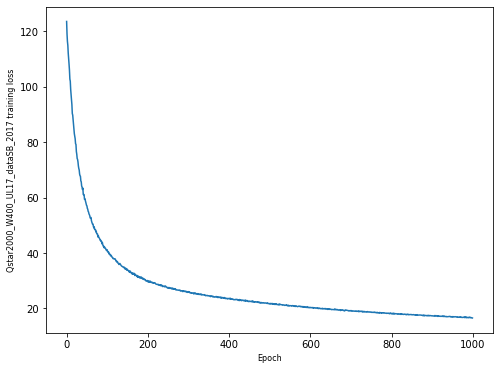

In [5]:
# Qstar2000_W400_UL17
sample = "Qstar2000_W400_UL17"
data,unnorm,mass,varNames = hf.LAPS_train(sample,year,num_batches=1,pt_cut=300,Mjj_cut=800)
data = hf.normalize_data(data,inp_mean=dataSB_mean,inp_std=dataSB_std)
train = data[:int(0.9*data.shape[0])]
test = data[int(0.9*data.shape[0]):]
flow = hf.train_pipeline(sample+"_dataSB_{0}".format(year),train,varNames,train_params,pt_cut=300,Mjj_cut=800)

Initial: 38347 events 
Final: 37046 events 
Removed 3.3927%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Loss:  183.88712
Loss:  178.91527
Loss:  173.08936
Loss:  167.57698
Loss:  162.92685
Loss:  158.2364
Loss:  153.86891
Loss:  149.72844
Loss:  144.4976
Loss:  141.24635
Loss:  137.14153
Loss:  134.61469
Loss:  130.2645
Loss:  126.138176
Loss:  122.99491
Loss:  120.29865
Loss:  117.24411
Loss:  113.99117
Loss:  110.954315
Iteration 20 Complete
Loss:  108.557014
SAVING MODEL
Time:  8.982756853103638
------------------------------------
Loss:  104.88044
Loss:  102.63718
Loss:  99.97677
Loss:  97.705986
Loss:  95.054344
Loss:  93.04834
Loss:  90.62658
Loss:  88.62644
Loss:  86.95788
Loss:  84.79649
Loss:  82.88692
Loss:  81.4153
Loss:  79.50879
Loss:  77.8279
Loss:  76.12223
Loss:  75.0658
Loss:  73.70213
Loss:  71.744545
Loss:  70.859985
Iteration 40 Complete
Loss:  69.53944
SAVING MODEL
Time:  17.851985454559326
------------------------------------

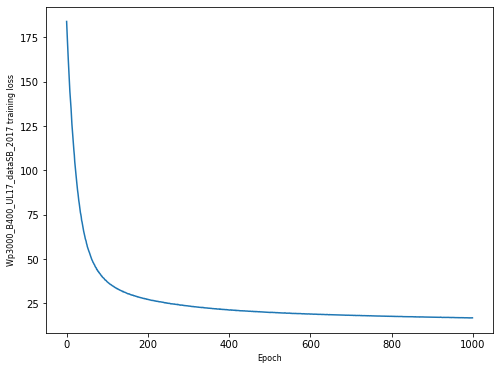

In [6]:
# Wp3000_B400_UL17
sample = "Wp3000_B400_UL17"
data,unnorm,mass,varNames = hf.LAPS_train(sample,year,num_batches=1,pt_cut=300,Mjj_cut=800)
data = hf.normalize_data(data,inp_mean=dataSB_mean,inp_std=dataSB_std)
train = data[:int(0.9*data.shape[0])]
test = data[int(0.9*data.shape[0]):]
flow = hf.train_pipeline(sample+"_dataSB_{0}".format(year),train,varNames,train_params,pt_cut=300,Mjj_cut=800)

Initial: 43758 events 
Final: 43735 events 
Removed 0.0526%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Loss:  117.907425
Loss:  108.24547
Loss:  102.703995
Loss:  94.61015
Loss:  91.383545
Loss:  86.29221
Loss:  81.570045
Loss:  76.56178
Loss:  72.74743
Loss:  69.60335
Loss:  66.43486
Loss:  63.019558
Loss:  62.22606
Loss:  58.66191
Loss:  58.710815
Loss:  56.115154
Loss:  54.740047
Loss:  53.22826
Loss:  51.687927
Iteration 20 Complete
Loss:  50.09966
SAVING MODEL
Time:  10.903858184814453
------------------------------------
Loss:  49.137215
Loss:  47.552757
Loss:  46.63146
Loss:  45.788933
Loss:  45.37849
Loss:  43.506977
Loss:  42.38408
Loss:  42.839268
Loss:  41.711605
Loss:  41.25491
Loss:  40.256264
Loss:  39.2208
Loss:  38.580357
Loss:  38.30561
Loss:  37.4483
Loss:  36.753563
Loss:  37.25957
Loss:  36.39063
Loss:  35.83384
Iteration 40 Complete
Loss:  35.883293
NOT SAVING MODEL (PATIENCE = 1)
Time:  21.705384969711304
-------------------

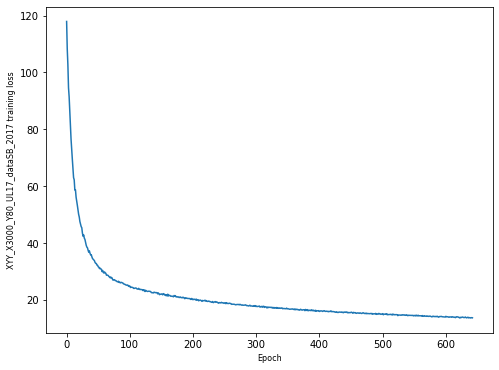

In [7]:
# XYY_X3000_Y80_UL17
sample = "XYY_X3000_Y80_UL17"
data,unnorm,mass,varNames = hf.LAPS_train(sample,year,num_batches=1,pt_cut=300,Mjj_cut=800)
data = hf.normalize_data(data,inp_mean=dataSB_mean,inp_std=dataSB_std)
train = data[:int(0.9*data.shape[0])]
test = data[int(0.9*data.shape[0]):]
flow = hf.train_pipeline(sample+"_dataSB_{0}".format(year),train,varNames,train_params,pt_cut=300,Mjj_cut=800)

# Trainings relative to QCDBKG mean/std

In [13]:
year = 2017
signal_samples = ["Qstar2000_W400_UL17","Wp3000_B400_UL17","XYY_X3000_Y80_UL17"]

train_params = {"flow_type":"NSRATQUAD","tail_bound":15,"hidden_features":120,
                "num_layers":6,"num_bins":40,"num_blocks_per_layer":4,
                "clip":15,"patience":20,"learning_rate":1e-3,"save_model":True,"bs":10000,"nmax":100000}

with h5py.File("bkgMeanStds/QCDBKG_{0}.h5".format(year),"r") as f:
    qcdbkg_mean = f["mean"][()]
    qcdbkg_std = f["std"][()]
with h5py.File("bkgMeanStds/dataSB_{0}.h5".format(year),"r") as f:
    dataSB_mean = f["mean"][()]
    dataSB_std = f["std"][()]

Initial: 32078 events 
Final: 31168 events 
Removed 2.8368%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Adjusting learning rate of group 0 to 1.0000e-03.
Loss:  45.51638
Adjusting learning rate of group 0 to 9.9976e-04.
Loss:  32.3656
Adjusting learning rate of group 0 to 9.9902e-04.
Loss:  29.248802
Adjusting learning rate of group 0 to 9.9780e-04.
Loss:  26.29281
Adjusting learning rate of group 0 to 9.9610e-04.
Loss:  24.639572
Adjusting learning rate of group 0 to 9.9391e-04.
Loss:  22.585533
Adjusting learning rate of group 0 to 9.9123e-04.
Loss:  21.02529
Adjusting learning rate of group 0 to 9.8808e-04.
Loss:  19.717024
Adjusting learning rate of group 0 to 9.8445e-04.
Loss:  18.391996
Adjusting learning rate of group 0 to 9.8035e-04.
Loss:  18.133986
Adjusting learning rate of group 0 to 9.7577e-04.
Loss:  17.295103
Adjusting learning rate of group 0 to 9.7074e-04.
Loss:  16.875547
Adjusting learning rate of group 0 to 9.6524e-04.
Loss:  1

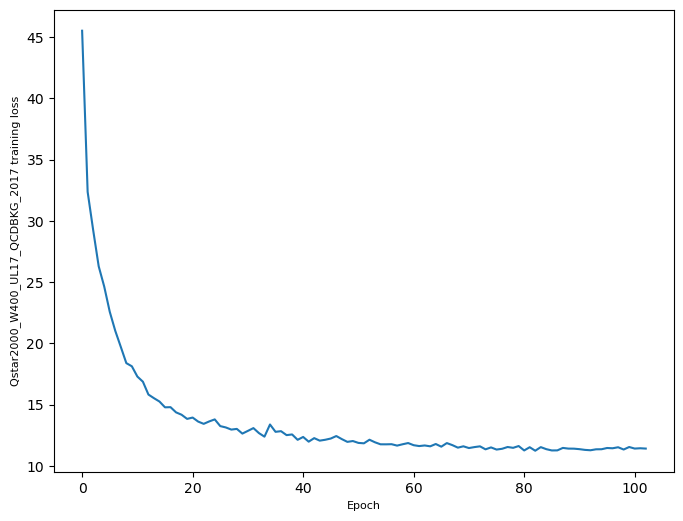

In [14]:
# Qstar2000_W400_UL17
sample = "Qstar2000_W400_UL17"
data,unnorm,mass,varNames = hf.LAPS_train(sample,year,num_batches=1,pt_cut=300,Mjj_cut=800)
data = hf.normalize_data(data,inp_mean=qcdbkg_mean,inp_std=qcdbkg_std)
train = data[:int(0.9*data.shape[0])]
test = data[int(0.9*data.shape[0]):]
flow,flowName = hf.train_pipeline(sample+"_QCDBKG_{0}".format(year),train,varNames,train_params,pt_cut=300,Mjj_cut=800)

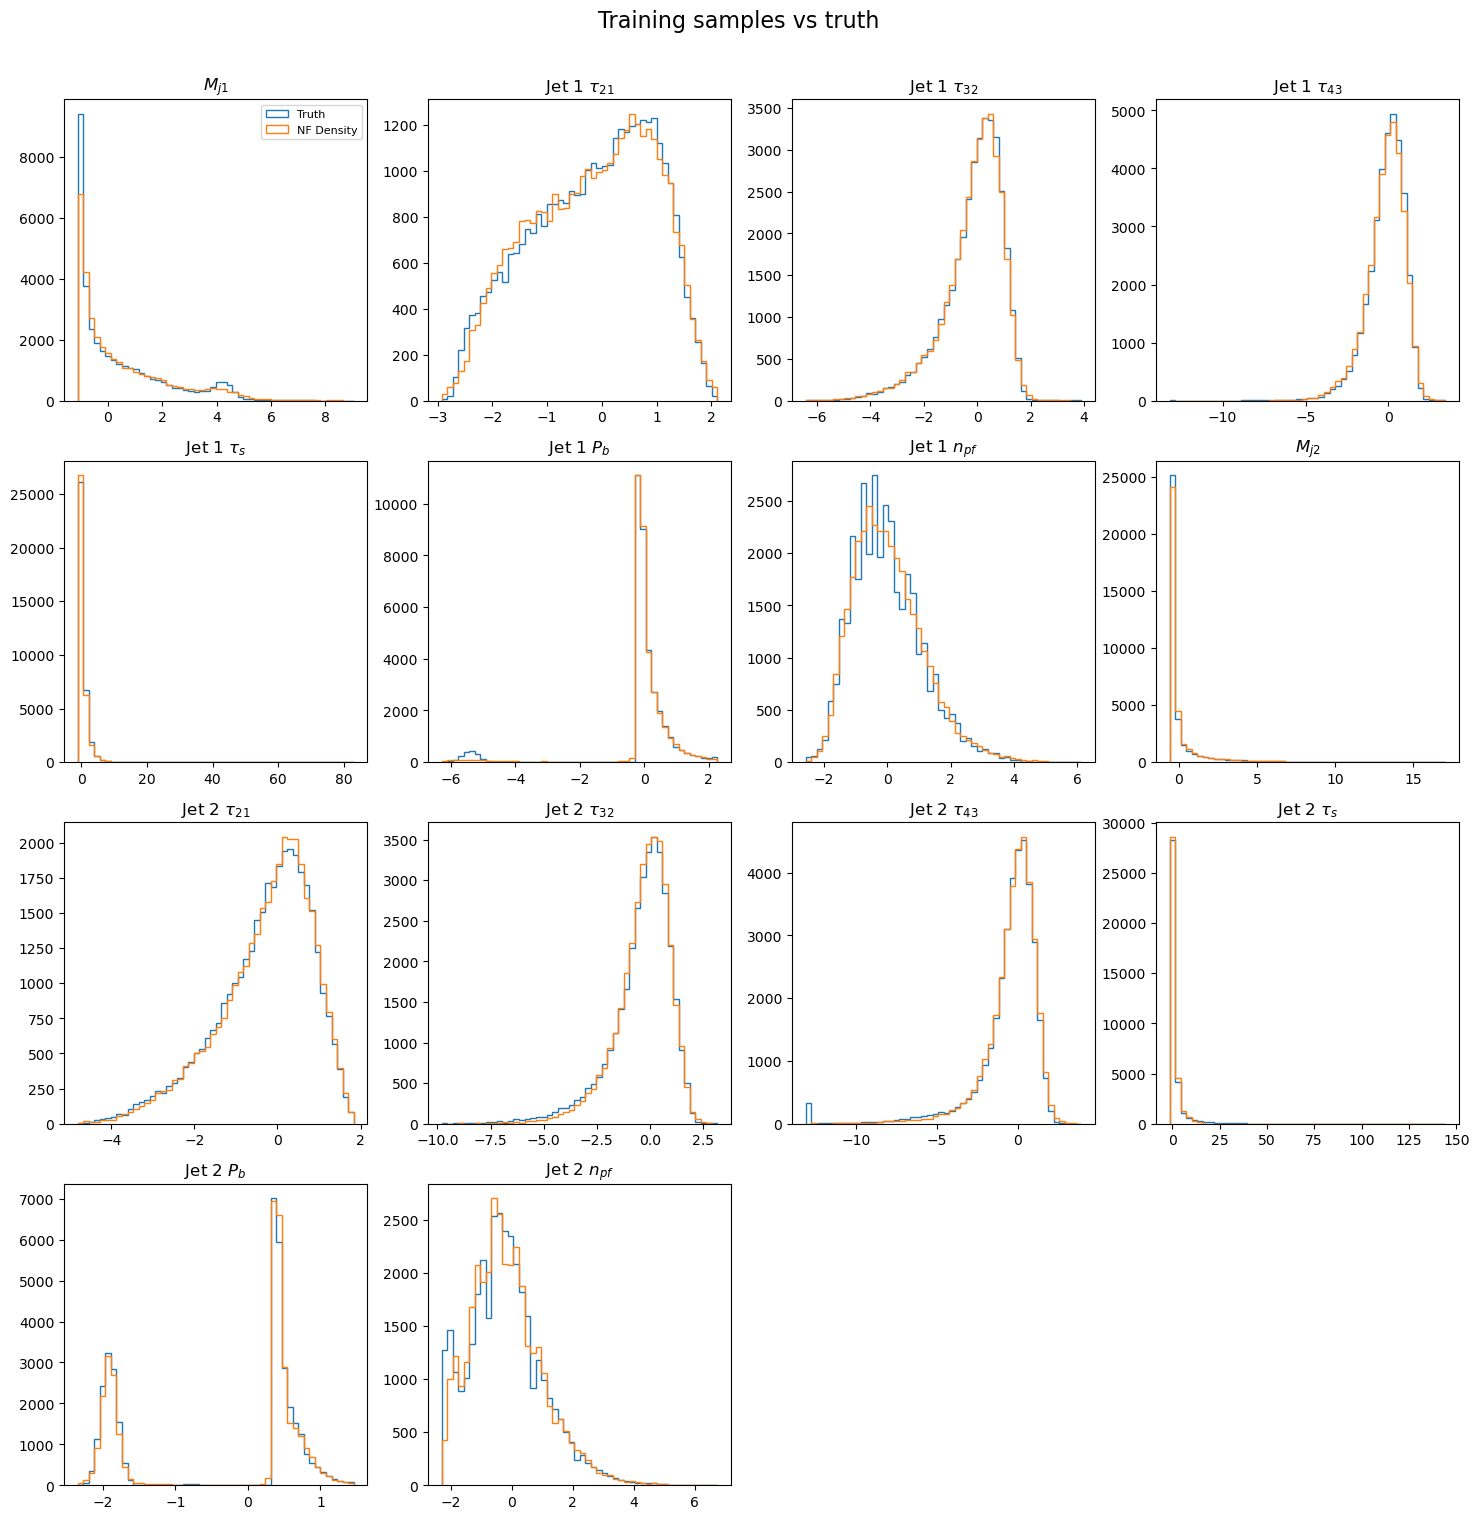

In [15]:
flow = hf.load_model(name=flowName)
hf.plot_density_estimation(flow,data,varNames,log=False)
del flow

Initial: 38347 events 
Final: 38339 events 
Removed 0.0209%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Adjusting learning rate of group 0 to 1.0000e-03.
Loss:  38.033173
Adjusting learning rate of group 0 to 9.9976e-04.
Loss:  31.505846
Adjusting learning rate of group 0 to 9.9902e-04.
Loss:  28.01144
Adjusting learning rate of group 0 to 9.9780e-04.
Loss:  25.408724
Adjusting learning rate of group 0 to 9.9610e-04.
Loss:  23.5924
Adjusting learning rate of group 0 to 9.9391e-04.
Loss:  21.477747
Adjusting learning rate of group 0 to 9.9123e-04.
Loss:  20.168365
Adjusting learning rate of group 0 to 9.8808e-04.
Loss:  19.049646
Adjusting learning rate of group 0 to 9.8445e-04.
Loss:  18.74282
Adjusting learning rate of group 0 to 9.8035e-04.
Loss:  18.808084
Adjusting learning rate of group 0 to 9.7577e-04.
Loss:  18.41617
Adjusting learning rate of group 0 to 9.7074e-04.
Loss:  17.49241
Adjusting learning rate of group 0 to 9.6524e-04.
Loss:  16

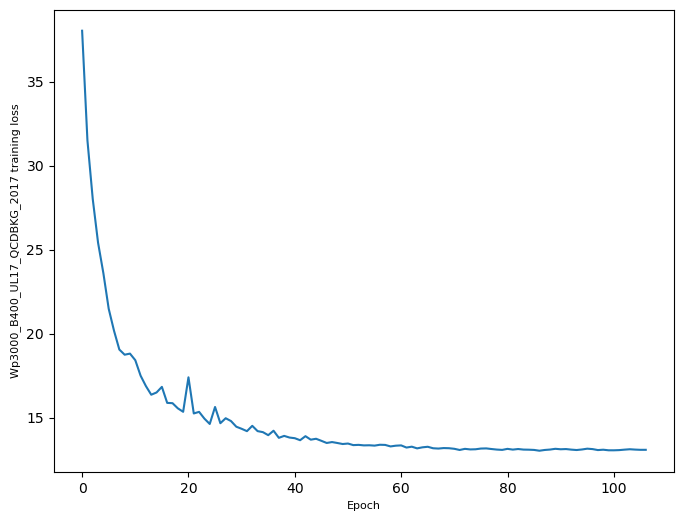

In [16]:
# Wp3000_B400_UL17
sample = "Wp3000_B400_UL17"
data,unnorm,mass,varNames = hf.LAPS_train(sample,year,num_batches=1,pt_cut=300,Mjj_cut=800)
data = hf.normalize_data(data,inp_mean=qcdbkg_mean,inp_std=qcdbkg_std)
train = data[:int(0.9*data.shape[0])]
test = data[int(0.9*data.shape[0]):]
flow,flowName = hf.train_pipeline(sample+"_QCDBKG_{0}".format(year),train,varNames,train_params,pt_cut=300,Mjj_cut=800)

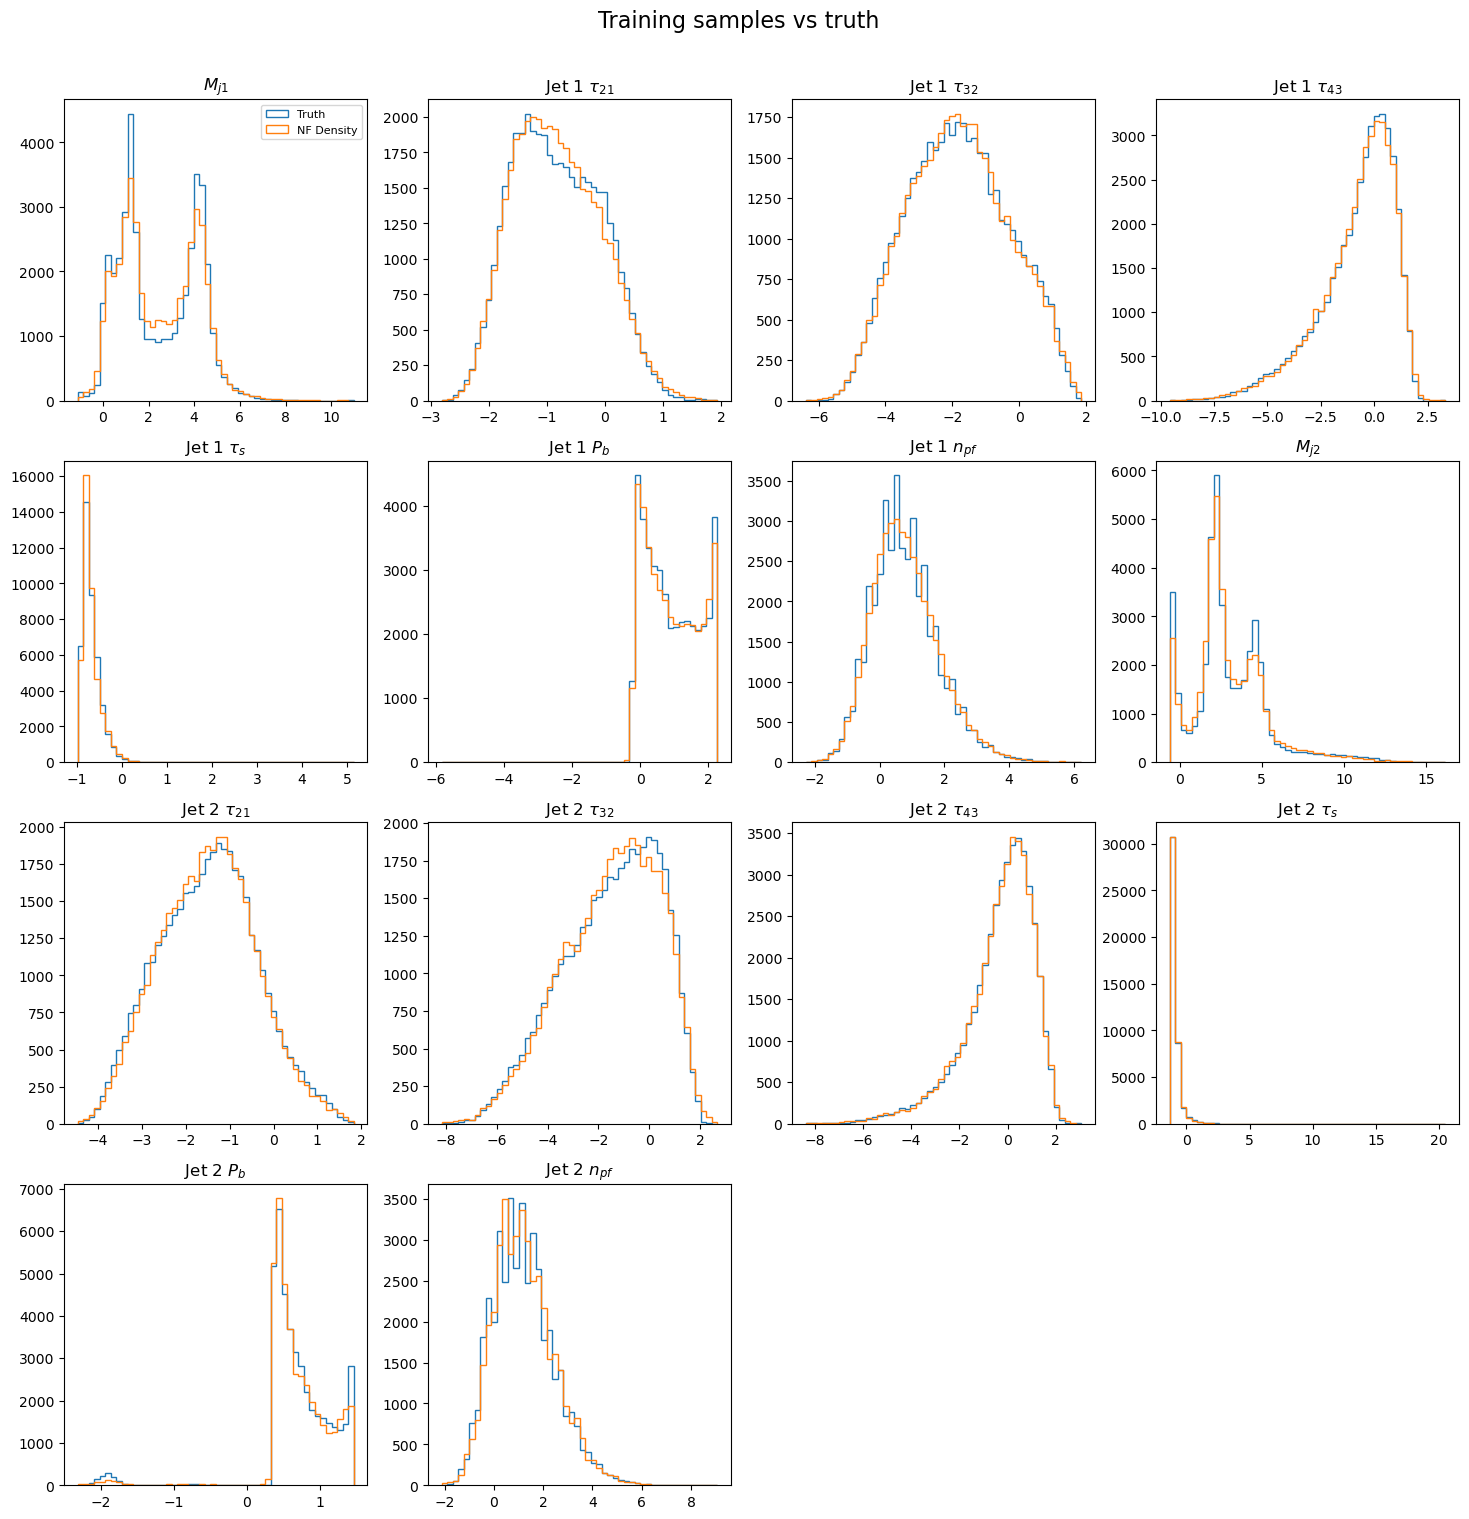

In [17]:
flow = hf.load_model(name=flowName)
hf.plot_density_estimation(flow,data,varNames,log=False)
del flow

Initial: 43758 events 
Final: 43758 events 
Removed 0.0000%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Adjusting learning rate of group 0 to 1.0000e-03.
Loss:  28.147024
Adjusting learning rate of group 0 to 9.9976e-04.
Loss:  23.728668
Adjusting learning rate of group 0 to 9.9902e-04.
Loss:  20.72824
Adjusting learning rate of group 0 to 9.9780e-04.
Loss:  17.932777
Adjusting learning rate of group 0 to 9.9610e-04.
Loss:  16.04214
Adjusting learning rate of group 0 to 9.9391e-04.
Loss:  14.839759
Adjusting learning rate of group 0 to 9.9123e-04.
Loss:  14.224767
Adjusting learning rate of group 0 to 9.8808e-04.
Loss:  13.375516
Adjusting learning rate of group 0 to 9.8445e-04.
Loss:  12.854693
Adjusting learning rate of group 0 to 9.8035e-04.
Loss:  12.485923
Adjusting learning rate of group 0 to 9.7577e-04.
Loss:  12.04652
Adjusting learning rate of group 0 to 9.7074e-04.
Loss:  11.861091
Adjusting learning rate of group 0 to 9.6524e-04.
Loss: 

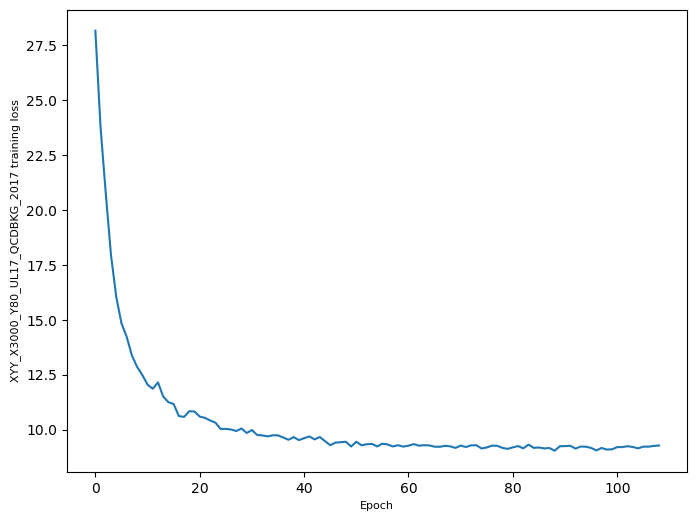

In [20]:
# XYY_X3000_Y80_UL17
sample = "XYY_X3000_Y80_UL17"
data,unnorm,mass,varNames = hf.LAPS_train(sample,year,num_batches=1,pt_cut=300,Mjj_cut=800)
data = hf.normalize_data(data,inp_mean=qcdbkg_mean,inp_std=qcdbkg_std)
train = data[:int(0.9*data.shape[0])]
test = data[int(0.9*data.shape[0]):]
flow,flowName = hf.train_pipeline(sample+"_QCDBKG_{0}".format(year),train,varNames,train_params,pt_cut=300,Mjj_cut=800)

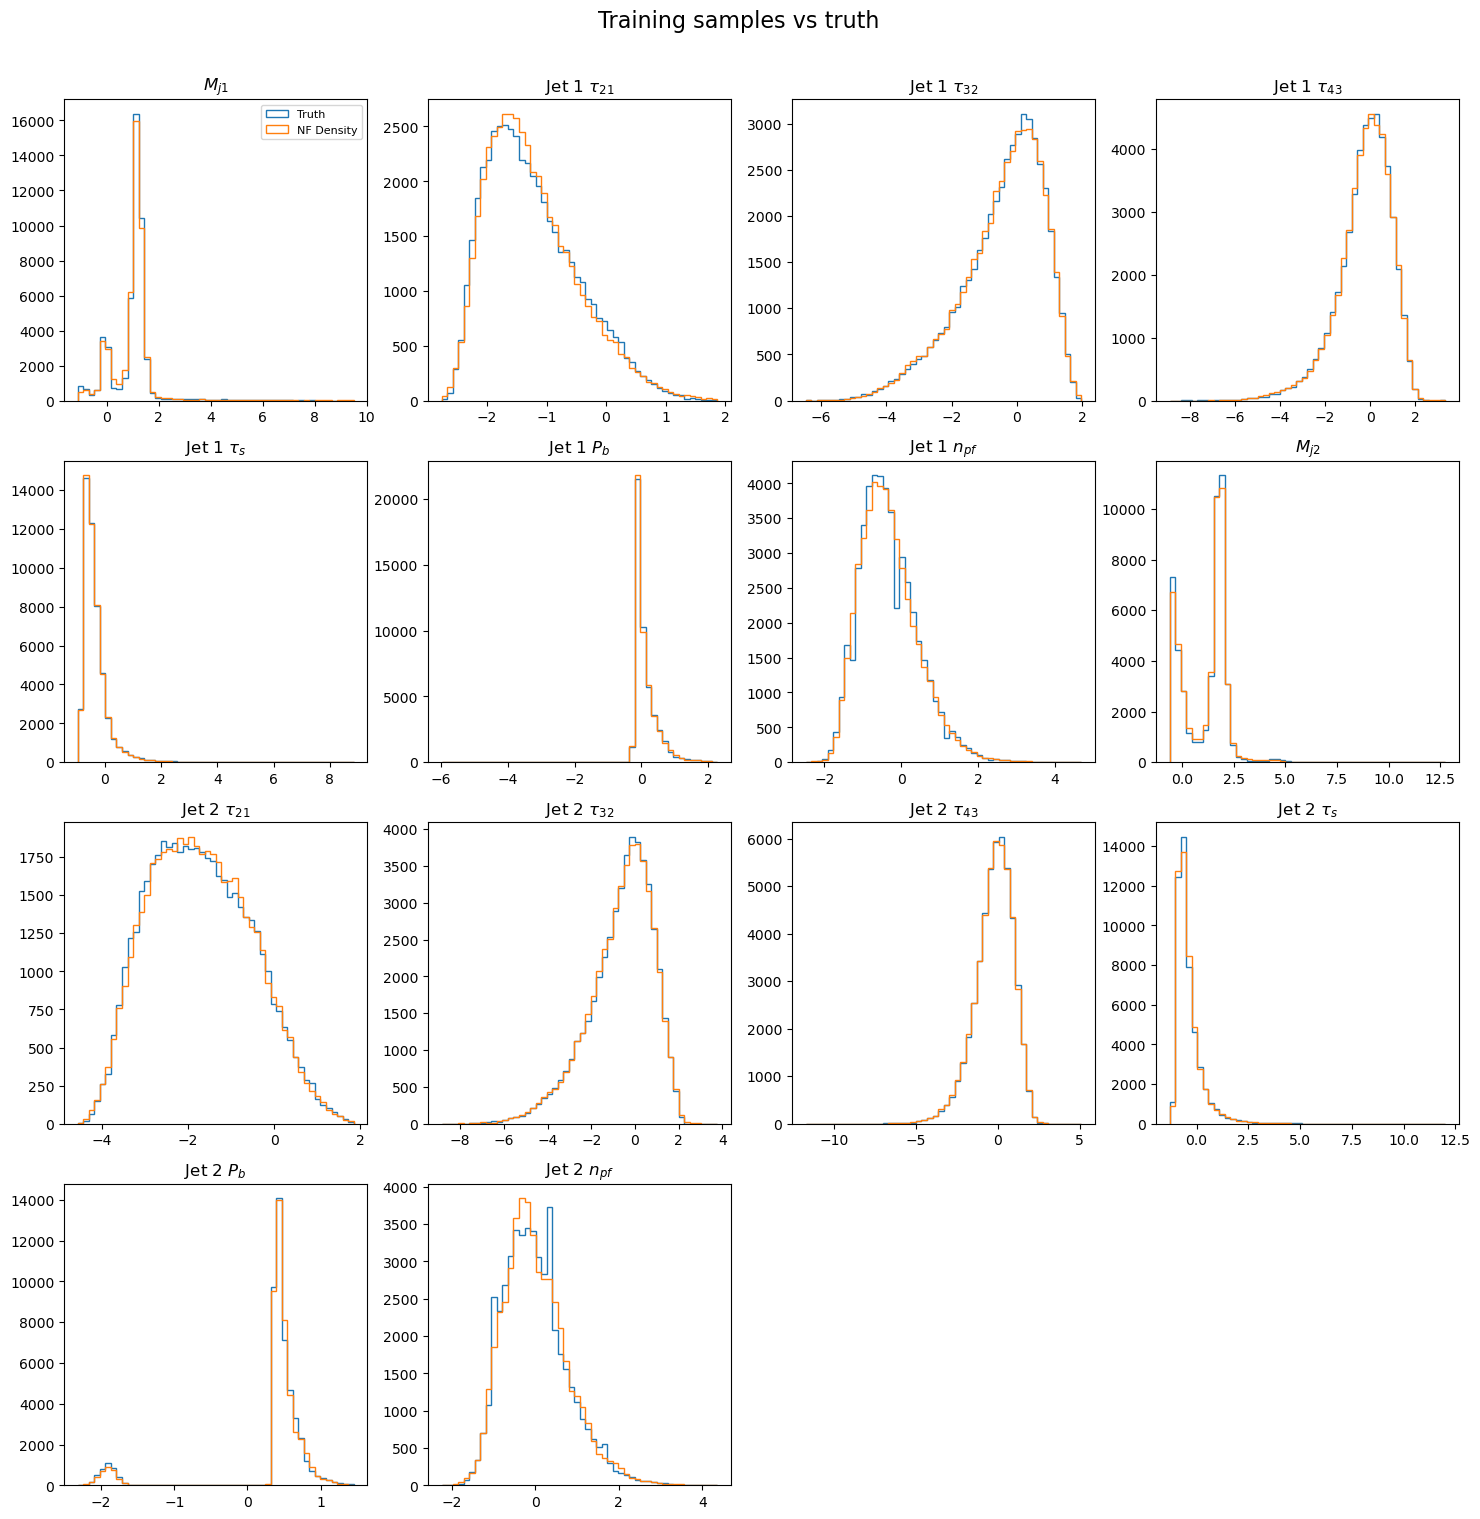

In [21]:
flow = hf.load_model(name=flowName)
hf.plot_density_estimation(flow,data,varNames,log=False)
del flow

Initial: 114183 events 
Final: 113259 events 
Removed 0.8092%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Adjusting learning rate of group 0 to 1.0000e-03.
Loss:  25.559378
Adjusting learning rate of group 0 to 9.9976e-04.
Loss:  21.000755
Adjusting learning rate of group 0 to 9.9902e-04.
Loss:  18.025448
Adjusting learning rate of group 0 to 9.9780e-04.
Loss:  17.065615
Adjusting learning rate of group 0 to 9.9610e-04.
Loss:  15.4994135
Adjusting learning rate of group 0 to 9.9391e-04.
Loss:  14.8806
Adjusting learning rate of group 0 to 9.9123e-04.
Loss:  15.06747
Adjusting learning rate of group 0 to 9.8808e-04.
Loss:  14.135068
Adjusting learning rate of group 0 to 9.8445e-04.
Loss:  13.953813
Adjusting learning rate of group 0 to 9.8035e-04.
Loss:  14.072684
Adjusting learning rate of group 0 to 9.7577e-04.
Loss:  13.584094
Adjusting learning rate of group 0 to 9.7074e-04.
Loss:  13.418481
Adjusting learning rate of group 0 to 9.6524e-04.
Los

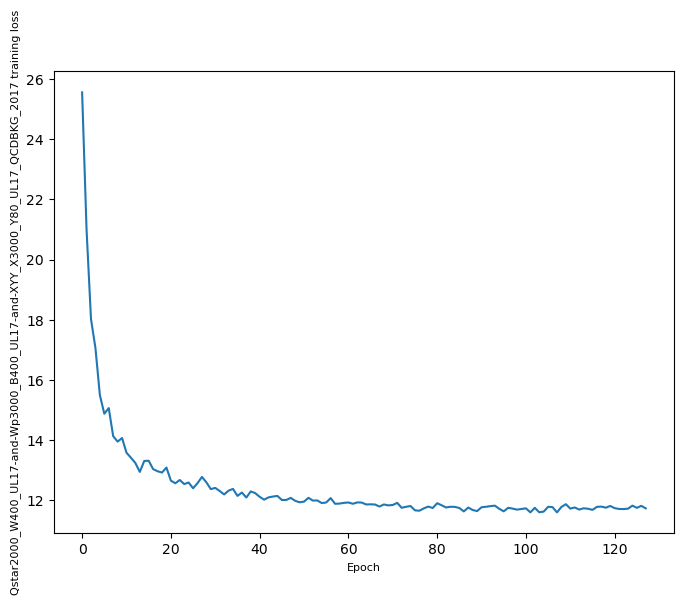

In [23]:
# combined training
datas = []
for s in signal_samples:
    data,unnorm,mass,varNames = hf.LAPS_train(s,year,num_batches=1,pt_cut=300,Mjj_cut=800)
    datas.append(data)
data = np.concatenate(datas,axis=0)
np.random.shuffle(data)
data = hf.normalize_data(data,inp_mean=qcdbkg_mean,inp_std=qcdbkg_std)
train = data[:int(0.9*data.shape[0])]
test = data[int(0.9*data.shape[0]):]
flowPrefix = "-and-".join(signal_samples)
flow,flowName = hf.train_pipeline(flowPrefix+"_QCDBKG_{0}".format(year),train,varNames,train_params,pt_cut=300,Mjj_cut=800)

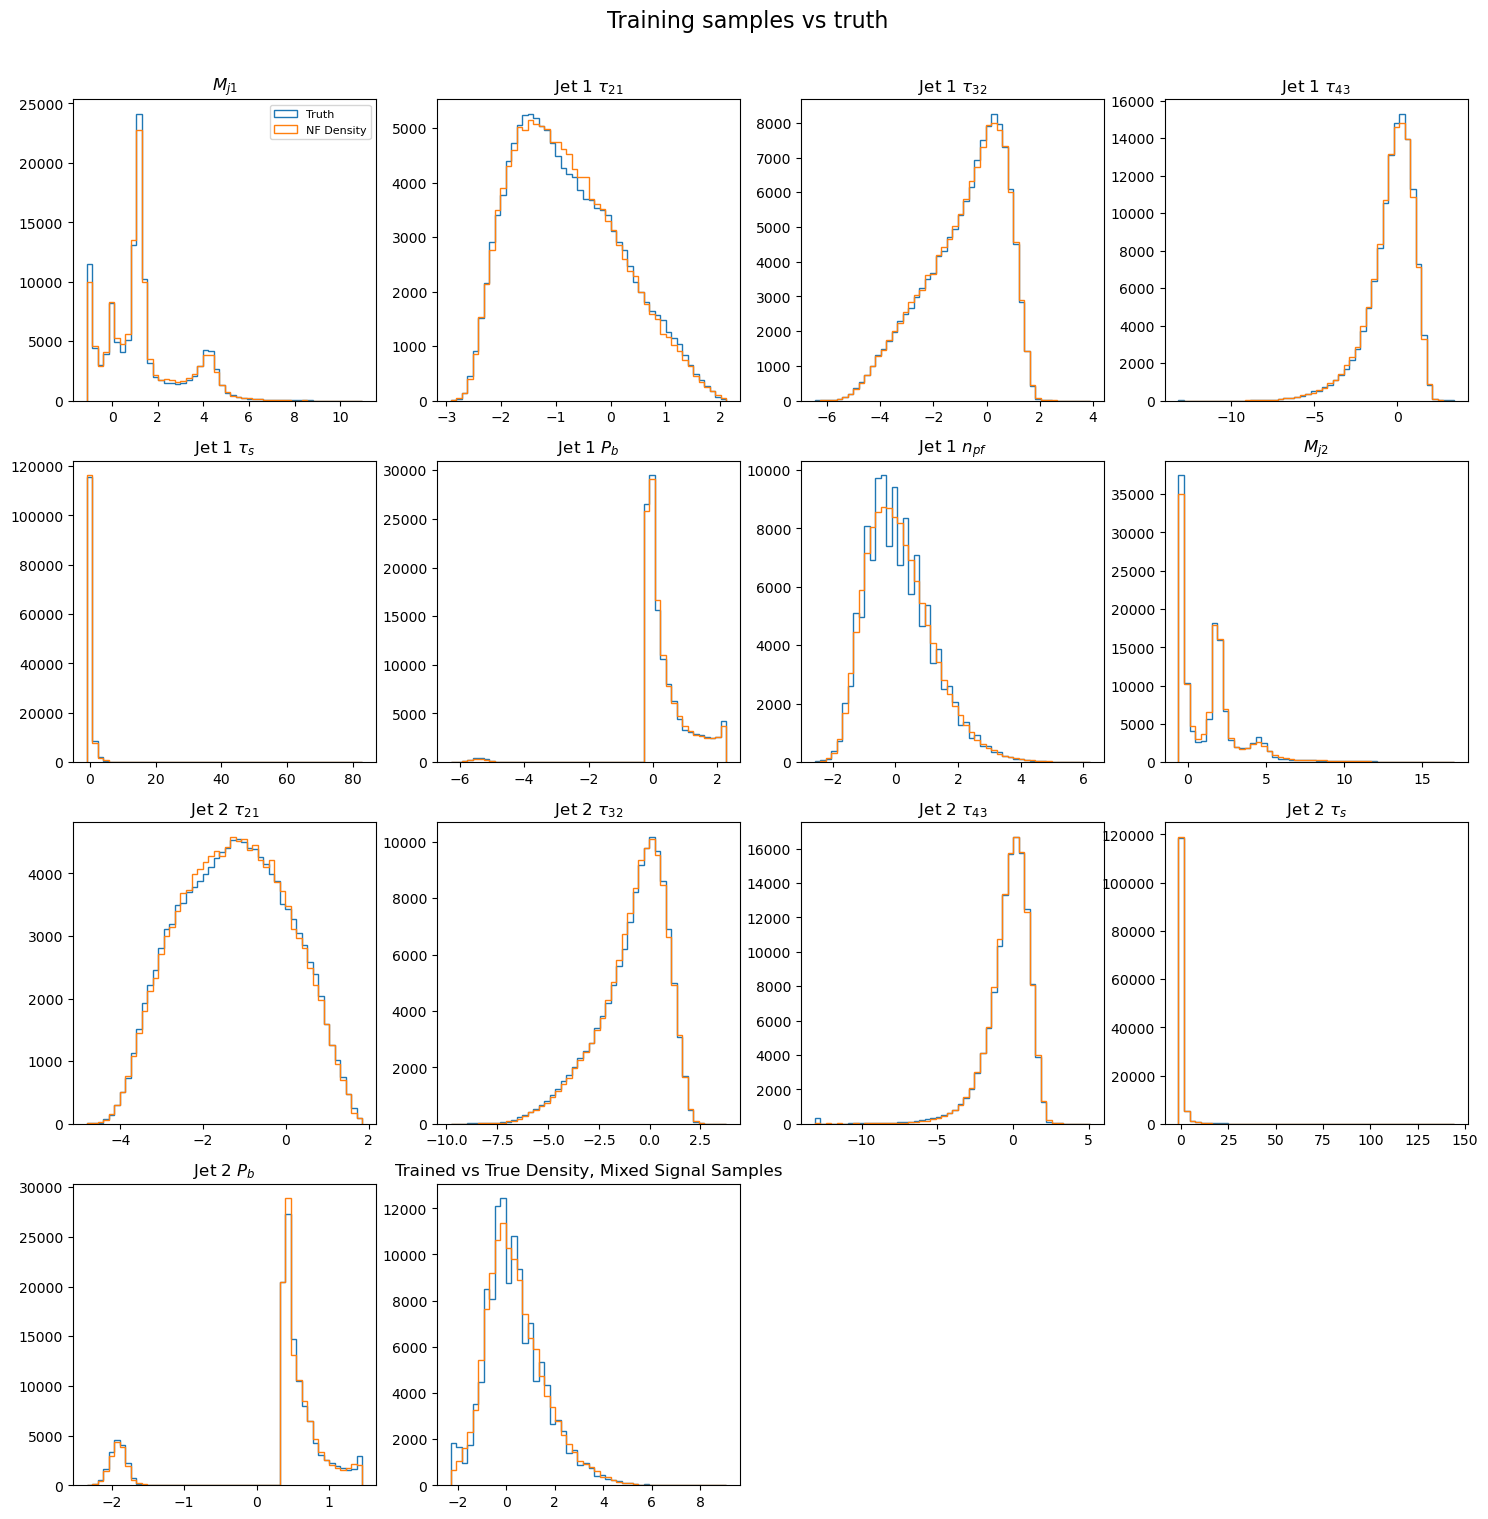

In [28]:
flow = hf.load_model(name=flowName)
hf.plot_density_estimation(flow,data,varNames,log=False)
plt.title("Trained vs True Density, Mixed Signal Samples")
plt.savefig("plots/training_plots/"+flowName.split(".")[0]+"/density_estimation.pdf")
del flow